In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import segmentation_models_pytorch as smp

# --- ПУТИ ---
TEST_IMG_DIR = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images"
YOLO_WEIGHTS = r"X:\Desktop\kaggle\solar_project_cv\models\yolo_detector\weights\best.pt"
MODELS_DIR = r"X:\Desktop\kaggle\solar_project_cv\models"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CFG_CROP_SIZE = 512
PAD_RATIO = 0.20

C:\Users\User\AppData\Local\Temp\ipykernel_11940\1149176295.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DE

Загружено моделей U-Net: 3

Анализ изображения: 20110120105534Ch.jpeg


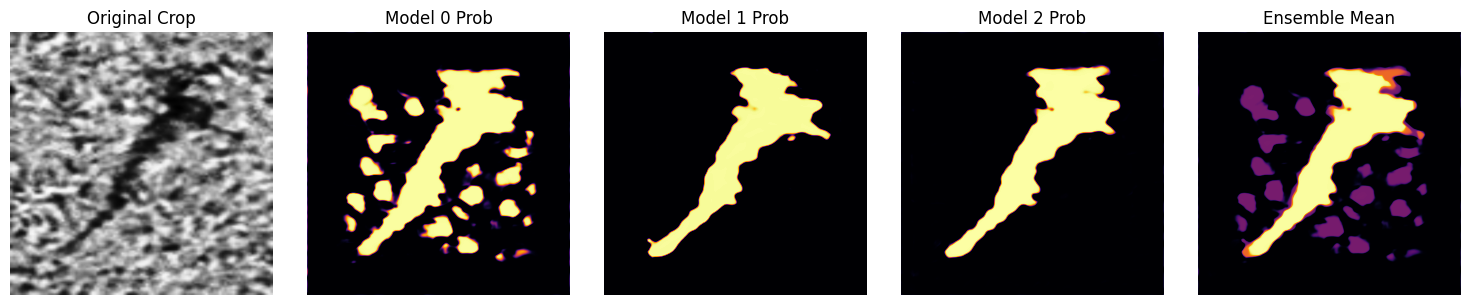

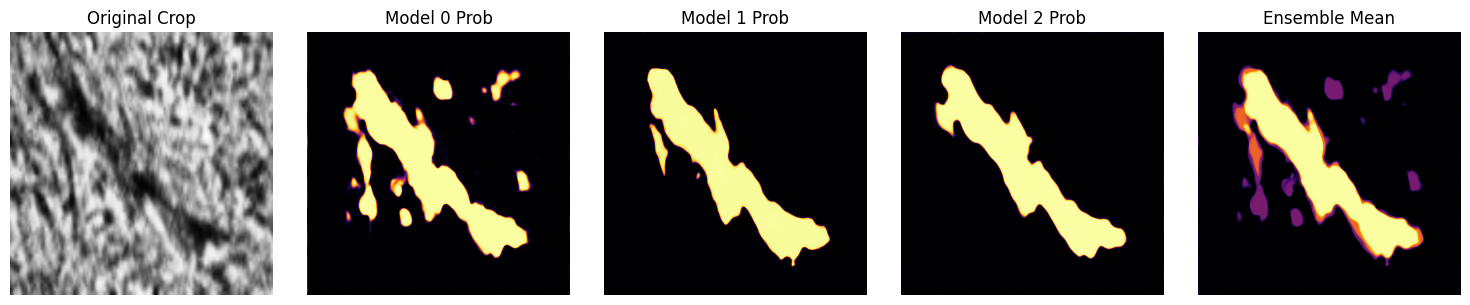


Анализ изображения: 20110130110334Ch.jpeg


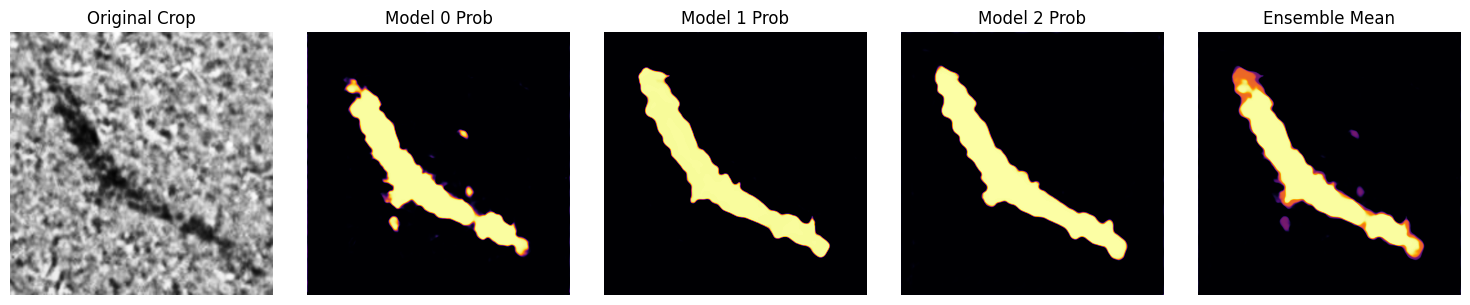

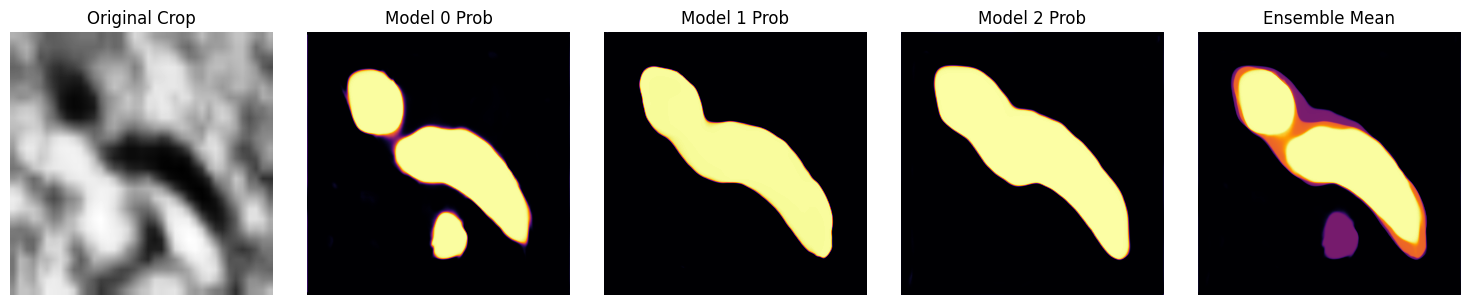


Анализ изображения: 20110214175414Mh.jpeg


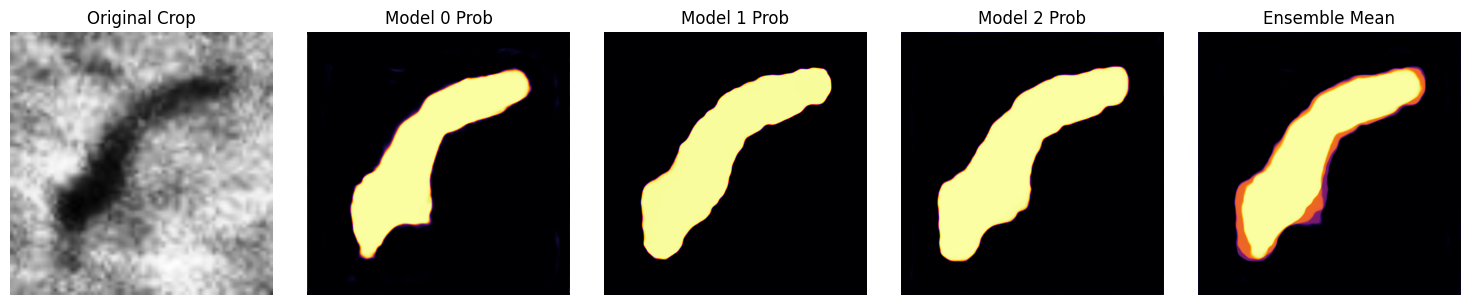

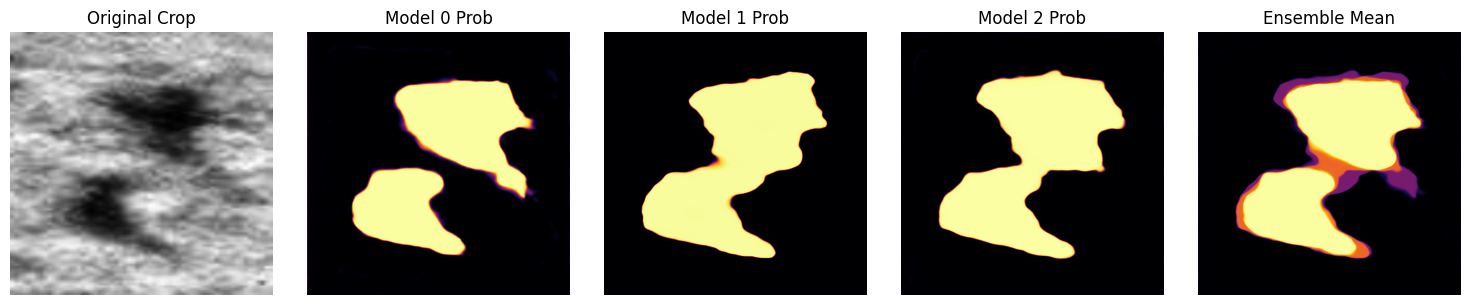

In [3]:
# 1. Загрузка детектора
det_model = YOLO(YOLO_WEIGHTS)

# 2. Загрузка всех 5 моделей в список
seg_models = []
for i in range(3):
    model_path = os.path.join(MODELS_DIR, f"best_seg_resnet34_fold_{i}.pth")
    model = smp.Unet(encoder_name='resnet34', in_channels=3, classes=1).to(DEVICE)
    # Если какие-то фолды еще не доучились, скрипт загрузит только те, что есть
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()
        seg_models.append(model)
    else:
        print(f"Внимание: {model_path} не найден.")

print(f"Загружено моделей U-Net: {len(seg_models)}")
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

# 3. Берем первые 3 картинки из теста для проверки
test_files = [f for f in sorted(os.listdir(TEST_IMG_DIR)) if f.endswith(('.jpeg', '.jpg'))][:3]

for fname in test_files:
    print(f"\nАнализ изображения: {fname}")
    img_path = os.path.join(TEST_IMG_DIR, fname)
    
    raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if len(raw_img.shape) > 2: raw_img = raw_img[:, :, 0]
    h, w = raw_img.shape[:2]
    
    disk_mask = raw_img > 15
    proc_img = raw_img.copy()
    if np.any(disk_mask):
        proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
    fused_img = np.stack([proc_img.astype(np.float32) / 255.0] * 3, axis=-1)

    # Детекция
    r = det_model.predict(img_path, imgsz=1280, conf=0.30, verbose=False)[0]
    boxes = r.boxes.xyxy.cpu().numpy()
    
    # Берем только первые 2 найденных филамента на каждой картинке, чтобы не засорять вывод
    for idx, box in enumerate(boxes[:2]):
        x1, y1, x2, y2 = box
        bw, bh = x2 - x1, y2 - y1
        pw, ph = bw * PAD_RATIO, bh * PAD_RATIO
        cx1, cy1 = max(0, int(x1 - pw)), max(0, int(y1 - ph))
        cx2, cy2 = min(w, int(x2 + pw)), min(h, int(y2 + ph))
        
        crop = cv2.resize(fused_img[cy1:cy2, cx1:cx2], (CFG_CROP_SIZE, CFG_CROP_SIZE))
        batch = torch.from_numpy(crop).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
        
        probs = []
        with torch.no_grad(), torch.amp.autocast('cuda'):
            for model in seg_models:
                p = torch.sigmoid(model(batch)).float().cpu().numpy()[0, 0]
                probs.append(p)
                
        ensemble_prob = np.mean(probs, axis=0)
        
        # 4. Отрисовка результатов
        fig, axes = plt.subplots(1, len(probs) + 2, figsize=(3 * (len(probs) + 2), 3))
        
        # Оригинальный кроп (показываем только первый канал для ЧБ)
        axes[0].imshow(crop[:, :, 0], cmap='gray')
        axes[0].set_title("Original Crop")
        axes[0].axis('off')
        
        # Предсказания каждой модели
        for i, p in enumerate(probs):
            axes[i+1].imshow(p, cmap='inferno', vmin=0, vmax=1)
            axes[i+1].set_title(f"Model {i} Prob")
            axes[i+1].axis('off')
            
        # Усредненный результат ансамбля
        axes[-1].imshow(ensemble_prob, cmap='inferno', vmin=0, vmax=1)
        axes[-1].set_title("Ensemble Mean")
        axes[-1].axis('off')
        
        plt.tight_layout()
        plt.show()

In [12]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import segmentation_models_pytorch as smp

# --- 1. ПУТИ И НАСТРОЙКИ ---
TEST_IMG_DIR = r"X:\Desktop\kaggle\solar_project_cv\notebooks\MAGFiLO_1.0_Kaggle_2026\test\test_images"
YOLO_WEIGHTS = r"X:\Desktop\kaggle\solar_project_cv\models\yolo_detector\weights\best.pt"
MODELS_DIR = r"X:\Desktop\kaggle\solar_project_cv\models"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CFG_CROP_SIZE = 512
PAD_RATIO = 0.20
MAX_FILAMENTS = 10 # Лимит вывода, чтобы не перегрузить график

# --- 2. ЗАГРУЗКА МОДЕЛЕЙ ---
det_model = YOLO(YOLO_WEIGHTS)

seg_models = []
for i in range(3):
    model_path = os.path.join(MODELS_DIR, f"best_seg_resnet34_fold_{i}.pth")
    if os.path.exists(model_path):
        model = smp.Unet(encoder_name='resnet34', in_channels=3, classes=1).to(DEVICE)
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        model.eval()
        seg_models.append(model)

print(f"Загружено моделей U-Net: {len(seg_models)}")
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

C:\Users\User\AppData\Local\Temp\ipykernel_11940\1359561618.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DE

Загружено моделей U-Net: 3


In [13]:
# --- 3. ВЫБИРАЕМ ОДНО ФОТО ---
test_files = [f for f in sorted(os.listdir(TEST_IMG_DIR)) if f.endswith(('.jpeg', '.jpg'))]
fname = test_files[100] # Берем самую первую картинку
img_path = os.path.join(TEST_IMG_DIR, fname)
print(f"\nАнализ изображения: {fname}")


Анализ изображения: 20150913082034Lh.jpeg


In [14]:
# --- 4. ПРЕДОБРАБОТКА И ИНФЕРЕНС YOLO ---
raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if len(raw_img.shape) > 2: raw_img = raw_img[:, :, 0]
h, w = raw_img.shape[:2]

disk_mask = raw_img > 15
proc_img = raw_img.copy()
if np.any(disk_mask):
    proc_img[disk_mask] = clahe.apply(raw_img)[disk_mask]
fused_img = np.stack([proc_img.astype(np.float32) / 255.0] * 3, axis=-1)

results = det_model.predict(img_path, imgsz=1280, conf=0.30, verbose=False)[0]
boxes = results.boxes.xyxy.cpu().numpy()
confs = results.boxes.conf.cpu().numpy()

# Сортируем по убыванию уверенности сети
sorted_indices = np.argsort(-confs)
boxes = boxes[sorted_indices]
confs = confs[sorted_indices]

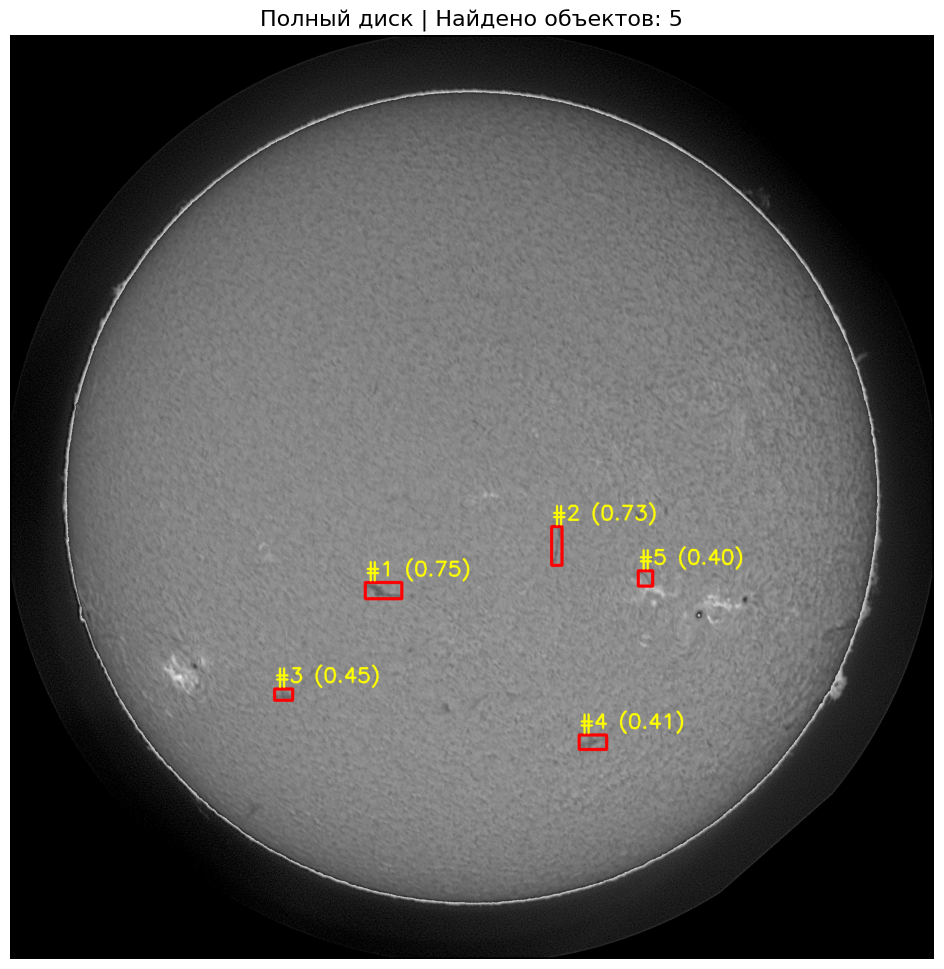


Детальный разбор 5 филаментов:


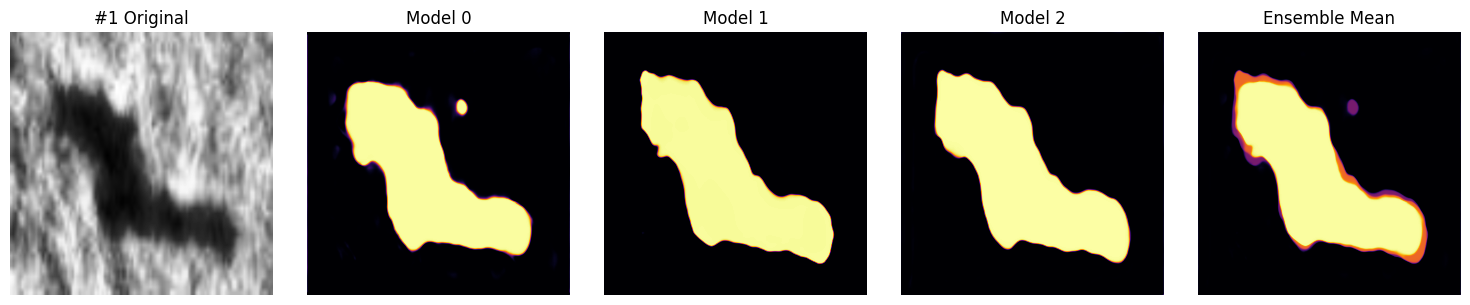

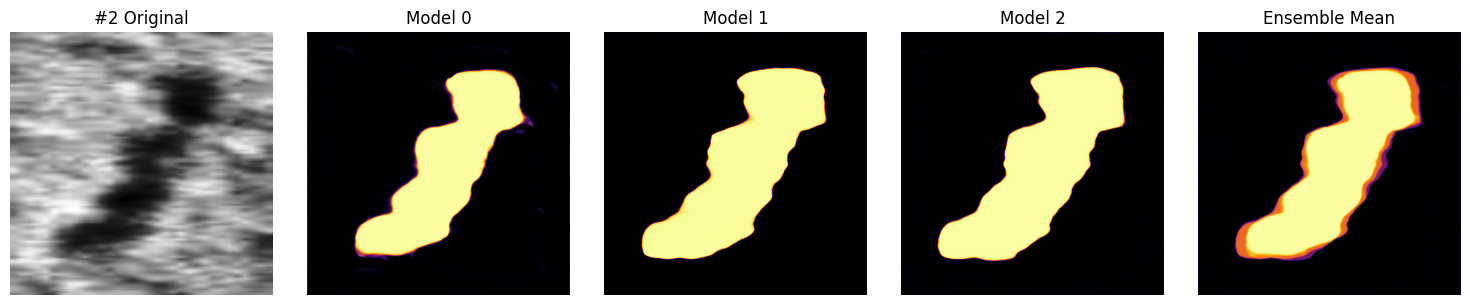

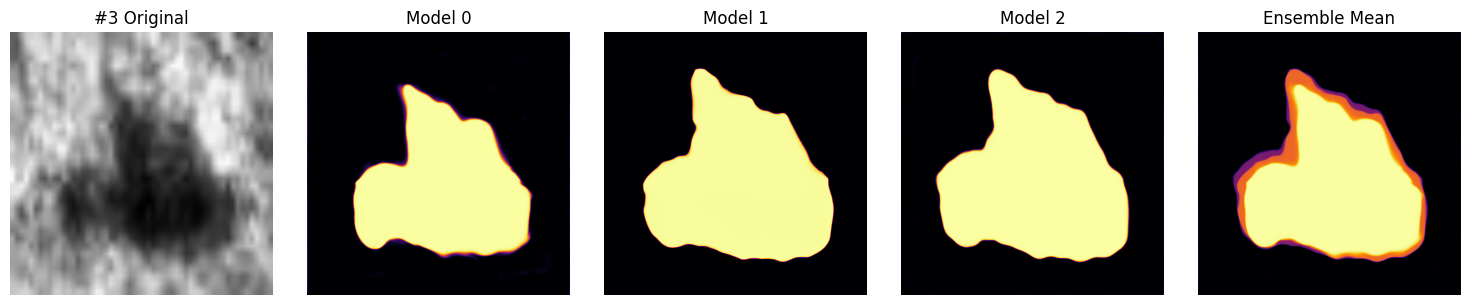

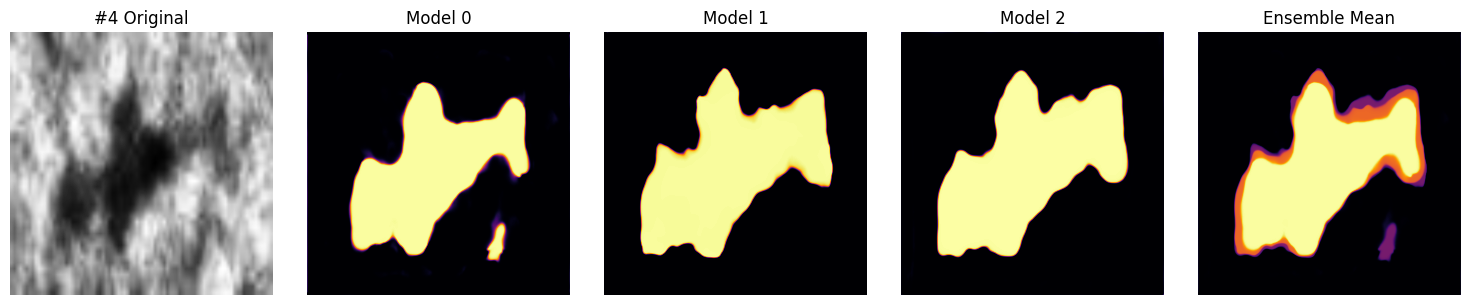

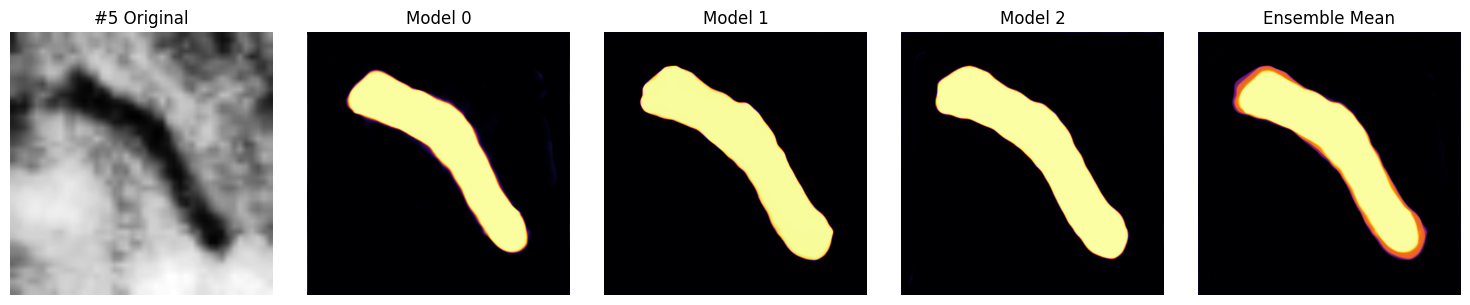

In [15]:
# --- 5. ОТРИСОВКА ОРИГИНАЛА С РАМКАМИ ---
img_color = cv2.cvtColor(raw_img, cv2.COLOR_GRAY2RGB)
for idx, (box, conf) in enumerate(zip(boxes, confs)):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img_color, (x1, y1), (x2, y2), (255, 0, 0), 6)
    cv2.putText(img_color, f"#{idx+1} ({conf:.2f})", (x1, max(y1 - 15, 20)), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 4)

plt.figure(figsize=(12, 12))
plt.imshow(img_color)
plt.title(f"Полный диск | Найдено объектов: {len(boxes)}", fontsize=16)
plt.axis('off')
plt.show()

# --- 6. ИНФЕРЕНС АНСАМБЛЯ И ОТРИСОВКА КРОПОВ ---
num_to_show = min(len(boxes), MAX_FILAMENTS)
print(f"\nДетальный разбор {num_to_show} филаментов:")

for idx in range(num_to_show):
    box = boxes[idx]
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    pw, ph = bw * PAD_RATIO, bh * PAD_RATIO
    cx1, cy1 = max(0, int(x1 - pw)), max(0, int(y1 - ph))
    cx2, cy2 = min(w, int(x2 + pw)), min(h, int(y2 + ph))
    
    crop = cv2.resize(fused_img[cy1:cy2, cx1:cx2], (CFG_CROP_SIZE, CFG_CROP_SIZE))
    batch = torch.from_numpy(crop).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    
    probs = []
    with torch.no_grad(), torch.amp.autocast('cuda'):
        for model in seg_models:
            p = torch.sigmoid(model(batch)).float().cpu().numpy()[0, 0]
            probs.append(p)
            
    ensemble_prob = np.mean(probs, axis=0)
    
    # Отрисовка строки для текущего филамента
    fig, axes = plt.subplots(1, len(probs) + 2, figsize=(3 * (len(probs) + 2), 3))
    
    axes[0].imshow(crop[:, :, 0], cmap='gray')
    axes[0].set_title(f"#{idx+1} Original")
    axes[0].axis('off')
    
    for i, p in enumerate(probs):
        axes[i+1].imshow(p, cmap='inferno', vmin=0, vmax=1)
        axes[i+1].set_title(f"Model {i}")
        axes[i+1].axis('off')
        
    axes[-1].imshow(ensemble_prob, cmap='inferno', vmin=0, vmax=1)
    axes[-1].set_title("Ensemble Mean")
    axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()